# Decision Tree Classifier


---

<br>

## What is a Decision Tree?
Answer: **Decision Tree** is a tree-like model used for decision-making and predictive modeling. It splits data into smaller subsets based on feature conditions, creating a tree structure of decision rules.

In Classification:
- It predicts **categorical target values** by learning decision rules from the data.
- The prediction is the **majority class** of the samples in the leaf node.

<br>

---

<br>

### Important Points:
1. **Tree Structure**:
   - The model splits the data based on features to form a tree.
   - Each **node** represents a decision (a feature), and each **leaf node** represents a class label (prediction).
   
2. **Splitting Criteria**:
   - It uses **Gini Impurity** or **Entropy** to decide the best feature for splitting at each node.
   - The aim is to make the groups at each leaf node as **pure as possible** (i.e., mostly one class).


3. **Recursion**:
   - The tree keeps splitting data recursively until it reaches stopping criteria like **max depth** or **minimum samples per leaf**.

4. **Overfitting**:
   - Decision Trees can overfit if they grow too deep, so controlling depth is important.

5. **Post-pruning**:
   - **Prunes back** the tree after it’s fully grown by removing branches that provide little predictive value, to improve generalization.

6. **Pre-pruning**:
   - **Stops the tree from growing too deep** by setting limits like maximum depth or minimum samples per leaf, to prevent overfitting.

7. **Interpretability**:
   - Decision Trees are easy to understand and visualize, making them a **transparent** model.

8. **Making Predictions**:
   - Predictions are made by **traversing** the tree from the root to the appropriate leaf node based on feature values.

<br>

---

<br>

### Key Parameters to Tune:

1. **`max_depth`**:
   - Limits the maximum depth of the tree.
   - Prevents overfitting by restricting how complex the tree can grow.
   - Example: `max_depth=3`

2. **`min_samples_split`**:
   - The minimum number of samples required to split an internal node.
   - Higher values prevent splits on small datasets.
   - Example: `min_samples_split=5`

3. **`min_samples_leaf`**:
   - The minimum number of samples required at a leaf node.
   - Controls the size of terminal nodes.
   - Example: `min_samples_leaf=2`

4. **`criterion`**:
   - Determines the function to measure the quality of a split.
   - Common options:
     - `squared_error` (default for regression): Minimizes the variance of the target variable.
     - `absolute_error`: Minimizes the absolute difference between predicted and actual values.

5. **`random_state`**:
   - Ensures reproducibility by fixing the random seed.
   - Example: `random_state=42`

<br>

---

<br>

### Advantages:
- Easy to interpret and visualize.
- Handles both numerical and categorical data.
- Non-parametric: No assumptions about data distribution.

<br>

### Disadvantages:
- Prone to overfitting on small datasets.
- Sensitive to small changes in the data.
- May require pruning or parameter tuning for optimal performance.

<br>


---

<br>

### Overview:
Decision Tree Classifier divides data into decision nodes, learns to split based on important features, and predicts by following the tree’s structure. It’s a powerful, interpretable model, but can overfit if not controlled.

<br>

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/51_iris.csv')

In [3]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df['petal_length'].min()

1.0

In [7]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: >

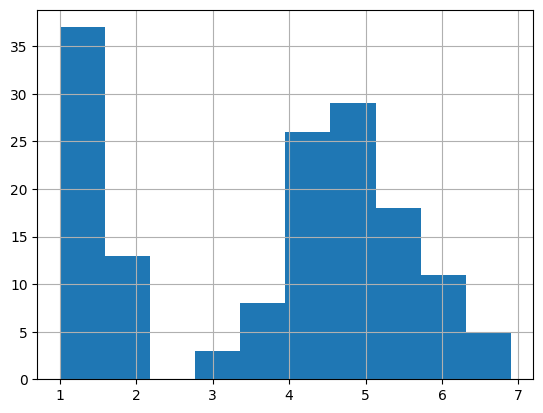

In [8]:
df.petal_length.hist()

<Axes: >

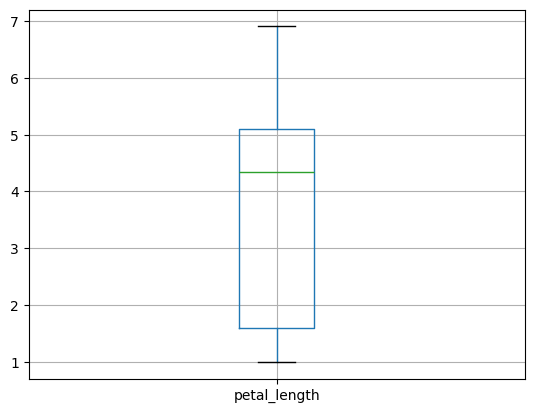

In [9]:
df.boxplot(column = ['petal_length'])

In [10]:
# Converting categorical values into numerical values using LabelEncoder and reflecting to the table using fit_transform
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [11]:
X = df.drop('species', axis = 1)
Y = df['species']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2, random_state=20)

In [13]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()

In [14]:
DT.fit(X_train, Y_train)

DecisionTreeClassifier()

[Text(0.3181818181818182, 0.9166666666666666, 'x[3] <= 0.8\ngini = 0.666\nsamples = 120\nvalue = [42, 39, 39]'),
 Text(0.22727272727272727, 0.75, 'gini = 0.0\nsamples = 42\nvalue = [42, 0, 0]'),
 Text(0.2727272727272727, 0.8333333333333333, 'True  '),
 Text(0.4090909090909091, 0.75, 'x[3] <= 1.65\ngini = 0.5\nsamples = 78\nvalue = [0, 39, 39]'),
 Text(0.36363636363636365, 0.8333333333333333, '  False'),
 Text(0.18181818181818182, 0.5833333333333334, 'x[2] <= 5.35\ngini = 0.051\nsamples = 38\nvalue = [0, 37, 1]'),
 Text(0.09090909090909091, 0.4166666666666667, 'gini = 0.0\nsamples = 37\nvalue = [0, 37, 0]'),
 Text(0.2727272727272727, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.6363636363636364, 0.5833333333333334, 'x[3] <= 1.75\ngini = 0.095\nsamples = 40\nvalue = [0, 2, 38]'),
 Text(0.45454545454545453, 0.4166666666666667, 'x[1] <= 2.75\ngini = 0.5\nsamples = 2\nvalue = [0, 1, 1]'),
 Text(0.36363636363636365, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 0,

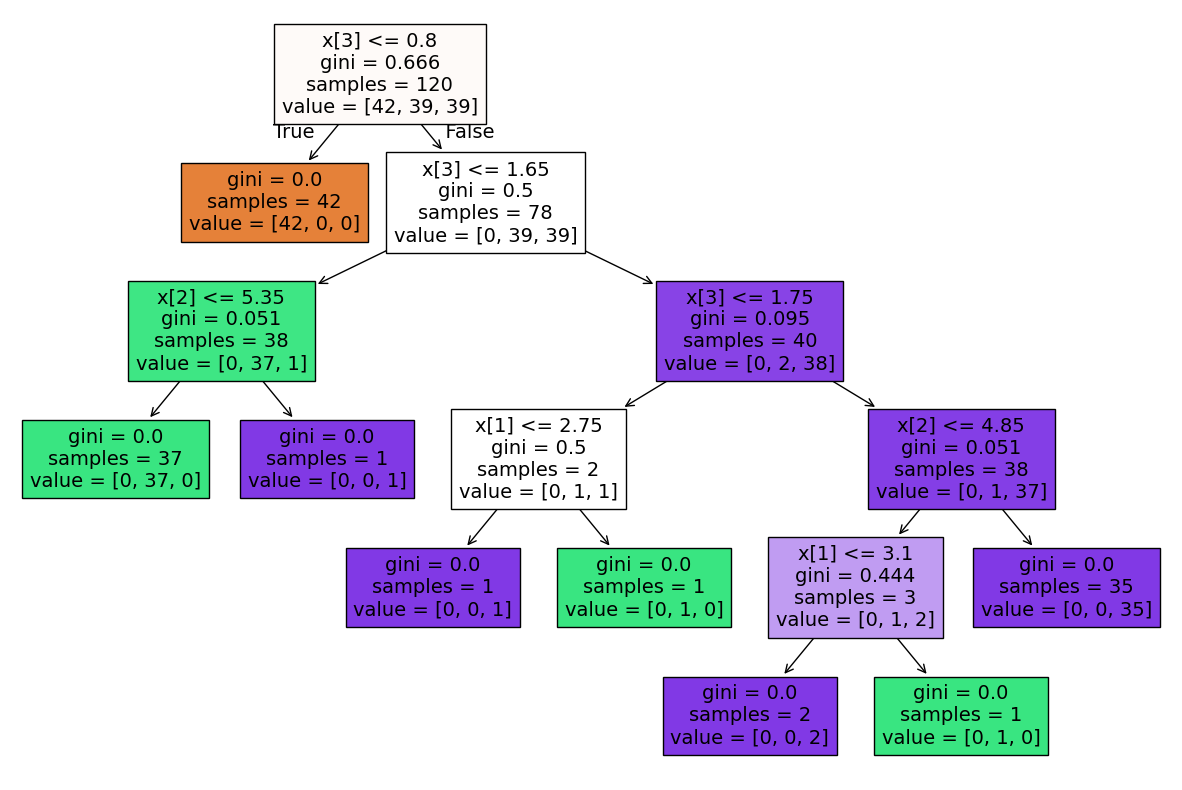

In [15]:
from sklearn import tree
plt.figure(figsize = (15,10))
tree.plot_tree(DT,filled = True)

In [16]:
Y_pred = DT.predict(X_test)

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(Y_test,Y_pred)

In [18]:
cm

array([[ 8,  0,  0],
       [ 0, 11,  0],
       [ 0,  2,  9]])

In [19]:
print(classification_report(Y_test,Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.85      1.00      0.92        11
           2       1.00      0.82      0.90        11

    accuracy                           0.93        30
   macro avg       0.95      0.94      0.94        30
weighted avg       0.94      0.93      0.93        30

